<a href="https://colab.research.google.com/github/manjunath1005/celebal-excellence-internship/blob/main/week6_Manjunath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 Assessment — Image Denoising using an Autoencoder (MNIST)

**Objective:** Build a deep learning model that removes noise from images using an autoencoder, trained and evaluated on the MNIST handwritten digits dataset.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

np.random.seed(42)
tf.random.set_seed(42)

## 1. Load the MNIST Dataset


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (60000, 28, 28)
Test shape : (10000, 28, 28)


In [3]:
# Normalize to [0, 1] and add a channel dimension -> (N, 28, 28, 1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Train shape:", x_train.shape, "\nTest shape:", x_test.shape)

Train shape: (60000, 28, 28, 1) 
Test shape: (10000, 28, 28, 1)


## 2. Create Noisy Versions of the Images

In this step, Gaussian noise is added to the original images to create noisy versions. Finally, the pixel values are clipped to keep them in the range of 0 to 1.

In [4]:
NOISE_FACTOR = 0.4  # controls how corrupted the input images are

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype("float32")

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

print("Noisy train shape:", x_train_noisy.shape)

Noisy train shape: (60000, 28, 28, 1)


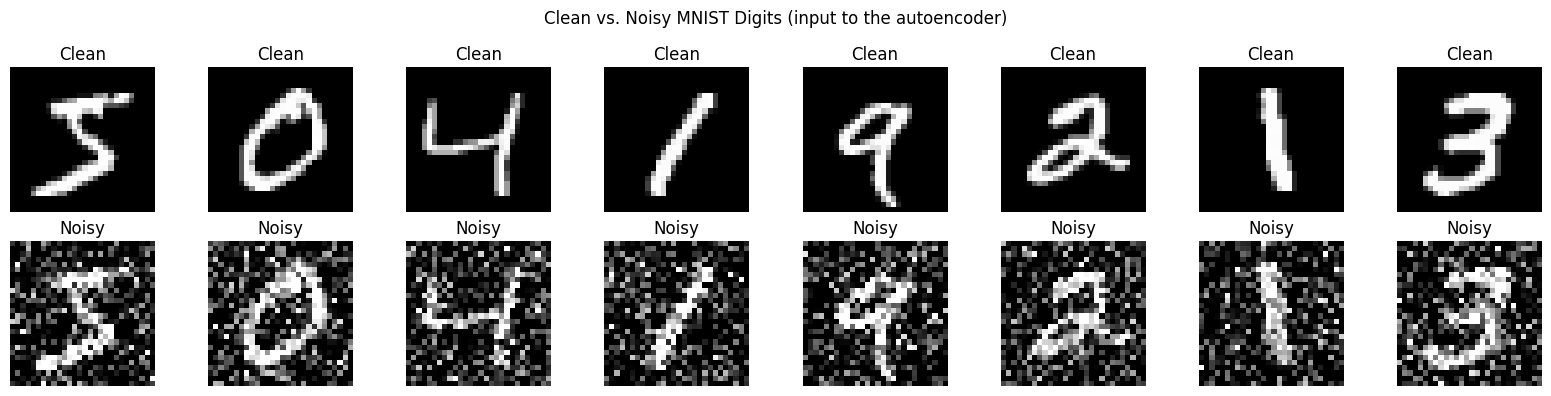

In [5]:
# Visualize: clean vs noisy
n = 8
plt.figure(figsize=(16, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")
plt.suptitle("Clean vs. Noisy MNIST Digits (input to the autoencoder)")
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# Split the data into train and validation sets
x_tr, x_val, x_tr_noisy, x_val_noisy = train_test_split(x_train, x_train_noisy, test_size=0.15, random_state=42)

print("Train:", x_tr.shape, "\nVal:", x_val.shape, "\nTest (held out):", x_test.shape)

Train: (51000, 28, 28, 1) 
Val: (9000, 28, 28, 1) 
Test (held out): (10000, 28, 28, 1)


## 3. Build the Convolutional Denoising Autoencoder

The model consists of two main parts:

- **Encoder:** It learns to compress the noisy input image into a smaller representation while keeping the important features.
- **Decoder:** It uses this compressed representation to reconstruct a clean version of the image.
- **Loss Function:** Binary cross-entropy is used to train the model because the image pixel values are normalized between 0 and 1. Mean Squared Error (MSE) is also calculated as an evaluation metric.

In [7]:
def build_denoising_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1), name="noisy_input")

    # ---- Encoder ----
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)          # 28x28 -> 14x14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same")(x)     # 14x14 -> 7x7

    # ---- Decoder ----
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D((2, 2))(x)                            # 7x7 -> 14x14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)                            # 14x14 -> 28x28
    decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="denoised_output")(x)

    autoencoder = models.Model(input_img, decoded, name="denoising_autoencoder")
    autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=["mse"])
    return autoencoder

autoencoder = build_denoising_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ denoised_output (Conv2D)        │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train the Model

The model learns the mapping **noisy image → clean image**. We validate on a held-out split of the *training* data (not the test set) to monitor generalization during training, keeping the test set fully unseen for final evaluation. Early stopping is used to avoid overfitting.

In [8]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = autoencoder.fit(
    x_tr_noisy, x_tr,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val),
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 0.1600 - mse: 0.0316 - val_loss: 0.1082 - val_mse: 0.0150
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1035 - mse: 0.0135 - val_loss: 0.0998 - val_mse: 0.0122
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0979 - mse: 0.0116 - val_loss: 0.0964 - val_mse: 0.0111
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0952 - mse: 0.0107 - val_loss: 0.0942 - val_mse: 0.0104
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0934 - mse: 0.0101 - val_loss: 0.0929 - val_mse: 0.0100
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0920 - mse: 0.0097 - val_loss: 0.0920 - val_mse: 0.0097
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0909 - mse: 0.0094 - val_loss: 0.0909 - val_mse: 0.0093
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0901 - mse: 0.0091 - val_loss: 0.0902 - val_mse: 0.0091
Epoch 9/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - 

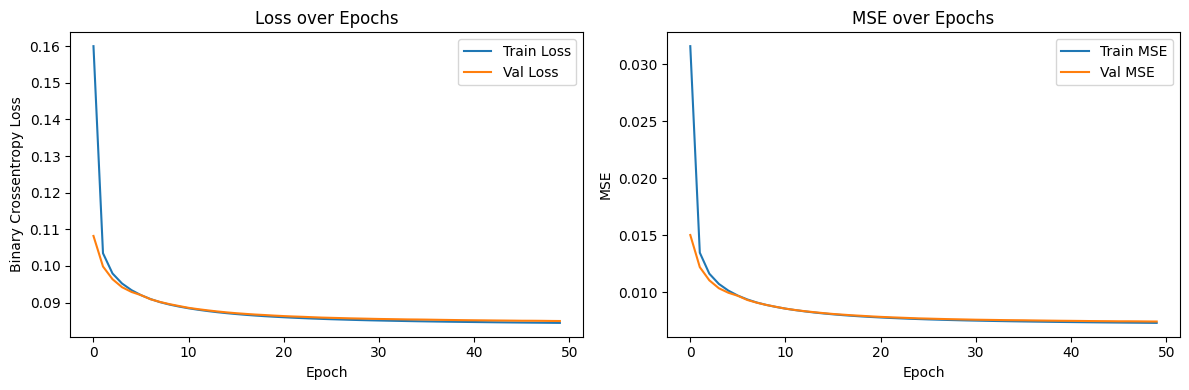

In [9]:
# Training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mse"], label="Train MSE")
plt.plot(history.history["val_mse"], label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

## 5. Evaluate the Denoising Performance

### 5.1 Visual comparison
Original (clean) vs. Noisy (input) vs. Denoised (model output), side by side.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


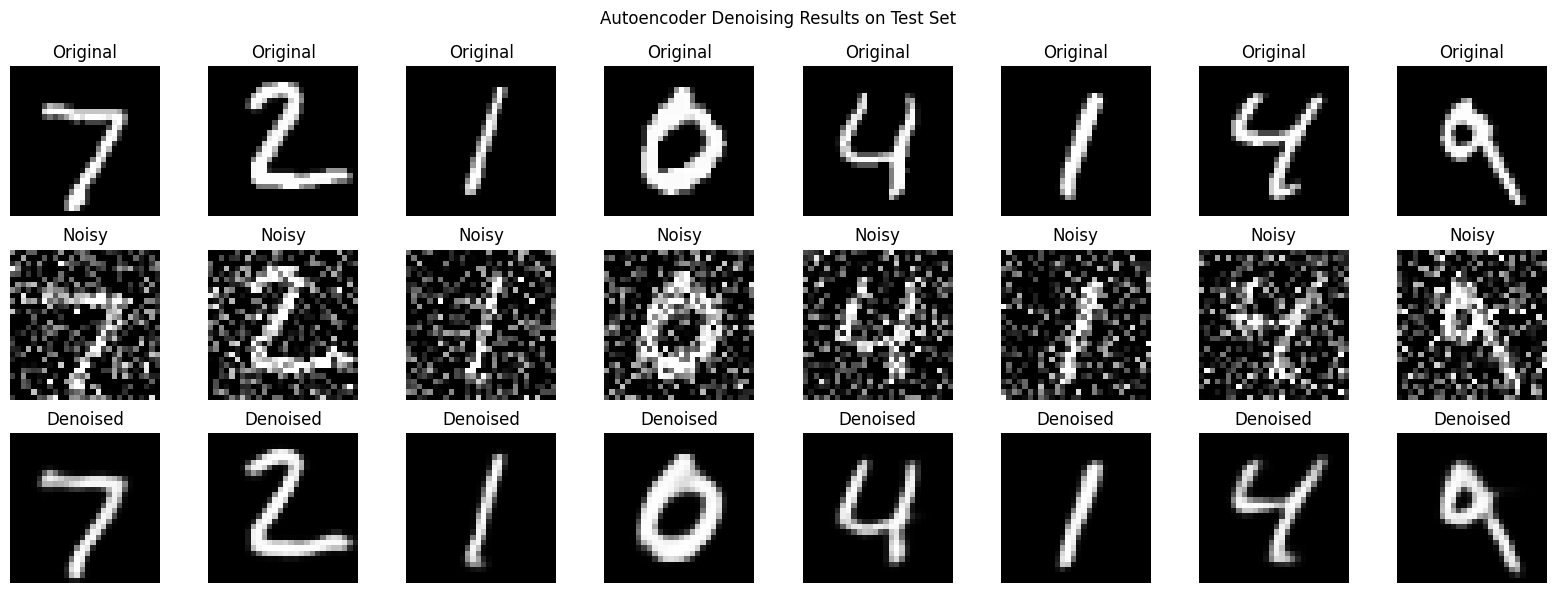

In [10]:
denoised_images = autoencoder.predict(x_test_noisy)

n = 8
plt.figure(figsize=(16, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.suptitle("Autoencoder Denoising Results on Test Set")
plt.tight_layout()
plt.show()

### 5.2 Quantitative metrics — PSNR and SSIM

- **PSNR (Peak Signal-to-Noise Ratio):** higher is better; measures pixel-level reconstruction fidelity.
- **SSIM (Structural Similarity Index):** ranges from -1 to 1 (closer to 1 is better); measures perceived structural similarity, which correlates better with human visual judgment than raw pixel error.

We compare **noisy vs. clean** (baseline, before denoising) against **denoised vs. clean** (after the autoencoder), to quantify the improvement.


In [11]:
def average_metrics(clean_imgs, comparison_imgs):
    psnr_scores, ssim_scores = [], []
    for c, d in zip(clean_imgs, comparison_imgs):
        c_img, d_img = c.squeeze(), d.squeeze()
        psnr_scores.append(psnr(c_img, d_img, data_range=1.0))
        ssim_scores.append(ssim(c_img, d_img, data_range=1.0))
    return np.mean(psnr_scores), np.mean(ssim_scores)

baseline_psnr, baseline_ssim = average_metrics(x_test, x_test_noisy)
denoised_psnr, denoised_ssim = average_metrics(x_test, denoised_images)

print(f"{'Metric':<10}{'Noisy (baseline)':<20}{'Denoised (model)':<20}")
print(f"{'PSNR':<10}{baseline_psnr:<20.3f}{denoised_psnr:<20.3f}")
print(f"{'SSIM':<10}{baseline_ssim:<20.3f}{denoised_ssim:<20.3f}")

Metric    Noisy (baseline)    Denoised (model)    
PSNR      11.004              21.680              
SSIM      0.446               0.909               


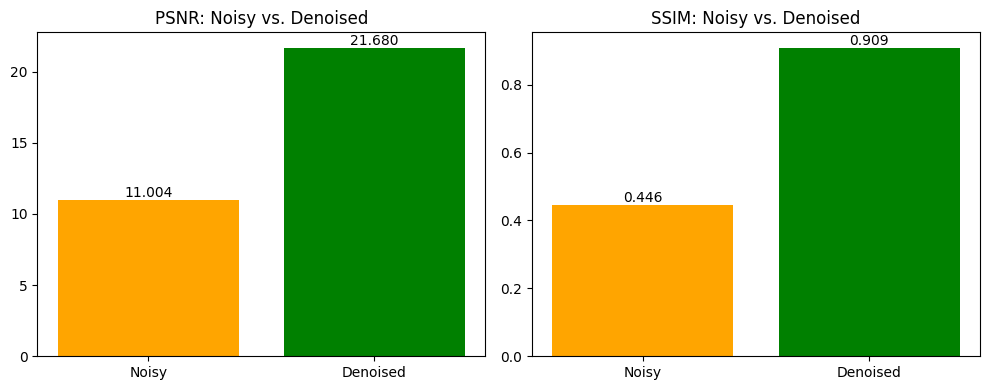

In [12]:
# Bar chart summary of the improvement
labels = ["PSNR", "SSIM"]
before = [baseline_psnr, baseline_ssim]
after = [denoised_psnr, denoised_ssim]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, label, b, a in zip(axes, labels, before, after):
    ax.bar(["Noisy", "Denoised"], [b, a], color=["orange", "green"])
    ax.set_title(f"{label}: Noisy vs. Denoised")
    for i, v in enumerate([b, a]):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 6. Conclusion & Analysis

### Results

I trained the autoencoder on MNIST digits after adding Gaussian noise (noise factor = 0.4) and tested it on 10,000 images that were never used during training or validation.

| Metric | Noisy Image | Denoised Image |
|--------|------------:|---------------:|
| PSNR | 11.00 | 21.68 |
| SSIM | 0.446 | 0.909 |

Both metrics improved significantly after denoising. PSNR nearly doubled, while SSIM increased from 0.446 to 0.909, showing that the reconstructed images are structurally very similar to the original digits. This was also reflected in the visual results, where the noisy digits became much clearer after reconstruction and the overall digit shapes were preserved.

### Observations

- The model learned quickly, with most of the improvement occurring during the first 15 epochs. After around epoch 20, the training and validation losses changed very little, indicating that the model had largely converged.
- The compressed representation (7 × 7 × 32) was sufficient to remove most of the noise while preserving the important features of the digits.
- I used a relatively high noise level (0.4), making many of the input images difficult to recognize. Even with this level of corruption, the model reconstructed the digits effectively, suggesting that it would likely perform even better with lower noise levels.

### Challenges Faced

- My initial implementation mistakenly used the test set as the validation set during training. Since early stopping selects the best model based on validation performance, this could indirectly influence the final evaluation. I corrected this by creating a separate validation split from the training data and using the test set only once for the final evaluation.
- Choosing an appropriate noise level required some experimentation. With too little noise, the denoising task becomes very easy, while excessive noise makes it difficult for the model to recover the original digit structure. A noise factor of 0.4 provided a good balance between these two cases.